In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

# Check if we are currently inside the 'notebooks' folder
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
from src.config import SimConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker

# Legacy Imports
from src.plants.fc_only_plant import FuelCellOnlyPlant
from src.solvers.sdp_baseline import BaselineSDPSolver
from src.controllers.stochastic import StochasticControl

# New Hybrid Imports
from src.plants.hybrid_plant import HybridPlant
from src.solvers.sdp_hybrid import HybridSDPSolver
from src.controllers.hybrid_controllers import (
    DiscreteTrackingControl,
    InterpolatedControl,
    LookaheadControl,
    NaiveHybridControl
)
from src.utils.plotting import plot_benchmarker_results

config = SimConfig()
fleet_data = load_and_cache_entire_fleet(config)

# Initialize benchmarker
exclude_days = [] 
benchmarker = VoyageBenchmarker(fleet_data, config, exclude_days)

Beginning memory staging of all 14 fleet files into RAM...
 -> Day 01 successfully cached in RAM.
 -> Day 02 successfully cached in RAM.
 -> Day 03 successfully cached in RAM.
 -> Day 04 successfully cached in RAM.
 -> Day 05 successfully cached in RAM.
 -> Day 06 successfully cached in RAM.
 -> Day 07 successfully cached in RAM.
 -> Day 08 successfully cached in RAM.
 -> Day 09 successfully cached in RAM.
 -> Day 10 successfully cached in RAM.
 -> Day 11 successfully cached in RAM.
 -> Day 12 successfully cached in RAM.
 -> Day 13 successfully cached in RAM.
 -> Day 14 successfully cached in RAM.

All 14 operational days securely held in RAM. Disk I/O locked.


In [4]:
# Builder wrappers for the Benchmarker cross-validation loops.
# The Benchmarker will pass the Markov Chain (mc) and Horizon dynamically.

def build_legacy_baseline(cfg, mc, horizon):
    """Legacy FC-Only operation (No battery plant)."""
    solver = BaselineSDPSolver(cfg, mc)
    policy, _ = solver.compute_solution(horizon)
    ctrl = StochasticControl(mc['levels'], cfg.n_vals, policy)
    return ctrl, FuelCellOnlyPlant(cfg)

def build_naive_hybrid(cfg, mc, horizon):
    """Battery exists in plant, but controller acts like it doesn't."""
    solver = BaselineSDPSolver(cfg, mc)
    policy, _ = solver.compute_solution(horizon)
    ctrl = NaiveHybridControl(mc['levels'], cfg.n_vals, policy)
    return ctrl, HybridPlant(cfg)

def build_discrete_tracking(cfg, mc, horizon):
    """Approach 3: Engineering Reality (Grid-locked PLC constraints)."""
    solver = HybridSDPSolver(cfg, mc)
    policy_n, policy_pbatt, _ = solver.compute_solution(horizon)
    ctrl = DiscreteTrackingControl(mc['levels'], cfg.n_vals, cfg.soc_vals, policy_n, policy_pbatt)
    return ctrl, HybridPlant(cfg)

def build_interpolated(cfg, mc, horizon):
    """Approach 2: Direct Approximation (Bilinear matrix smoothing)."""
    solver = HybridSDPSolver(cfg, mc)
    policy_n, policy_pbatt, _ = solver.compute_solution(horizon)
    ctrl = InterpolatedControl(mc['levels'], cfg.n_vals, cfg.soc_vals, policy_n, policy_pbatt)
    return ctrl, HybridPlant(cfg)

def build_lookahead(cfg, mc, horizon):
    """Approach 1: Theoretical Optimum (Online 1-step action resolution)."""
    solver = HybridSDPSolver(cfg, mc)
    _, _, V = solver.compute_solution(horizon)
    ctrl = LookaheadControl(cfg, mc['levels'], mc['P'], V)
    return ctrl, HybridPlant(cfg)

approaches = {
    "1. FC-Only Baseline": build_legacy_baseline,
    "2. Naive Hybrid (Hardware Only)": build_naive_hybrid,
    "3. Hybrid (Discrete Tracking)": build_discrete_tracking,
    "4. Hybrid (Interpolated)": build_interpolated,
    "5. Hybrid (Lookahead Optimum)": build_lookahead
}

In [5]:
print("--- APPROACH A: HAND-PICKED EVALUATION ---")
# Manually choose training block and test validation target
train_days = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
test_day = 14
df_manual = benchmarker.compare_approaches(approaches, train_days, test_day)
display(df_manual)

--- APPROACH A: HAND-PICKED EVALUATION ---


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€],Computation Time [s]
1. FC-Only Baseline,6509.970126,6453.720126,56.25,0.0,0.000000,0.237279
2. Naive Hybrid (Hardware Only),6472.005479,6352.564900,56.25,0.0,63.190579,0.306847
3. Hybrid (Discrete Tracking),6157.638335,6013.684646,56.25,0.0,87.703689,3.568511
4. Hybrid (Interpolated),6133.280898,5993.220903,56.25,0.0,83.809995,3.686542
5. Hybrid (Lookahead Optimum),6033.024467,5941.168444,0.00,0.0,91.856024,3.711053



--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€],Computation Time [s]
Day 1,2395.903354,2339.653354,56.25,0.0,0.0,0.252625
Day 2,2320.641499,2264.391499,56.25,0.0,0.0,0.262614
Day 3,7552.170682,7495.920682,56.25,0.0,0.0,0.262001
Day 4,8577.905125,8521.655125,56.25,0.0,0.0,0.277983
Day 5,6547.270194,6491.020194,56.25,0.0,0.0,0.213476
Day 6,6735.501000,6679.251000,56.25,0.0,0.0,0.260624
Day 7,6874.922406,6818.672406,56.25,0.0,0.0,0.204040
Day 8,6733.091683,6676.841683,56.25,0.0,0.0,0.227050
Day 9,7963.844510,7907.594510,56.25,0.0,0.0,0.214596
Day 10,7401.472439,7345.222439,56.25,0.0,0.0,0.196958


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€],Computation Time [s]
Day 1,2447.802981,2358.097657,56.25,0.0,33.455324,3.509186
Day 2,2379.686492,2291.234934,56.25,0.0,32.201558,3.279200
Day 3,7157.986169,7065.510946,56.25,0.0,36.225223,3.617139
Day 4,8231.292522,8085.441666,56.25,0.0,89.600855,3.461939
Day 5,6423.411808,6314.662103,56.25,0.0,52.499705,3.204900
Day 6,6477.364116,6347.465221,56.25,0.0,73.648895,3.183085
Day 7,6538.453319,6393.206626,56.25,0.0,88.996693,3.183295
Day 8,6471.203747,6335.759637,56.25,0.0,79.194109,3.231411
Day 9,7655.511395,7519.663995,56.25,0.0,79.597400,3.091609
Day 10,7106.290832,6978.414353,56.25,0.0,71.626479,3.094074


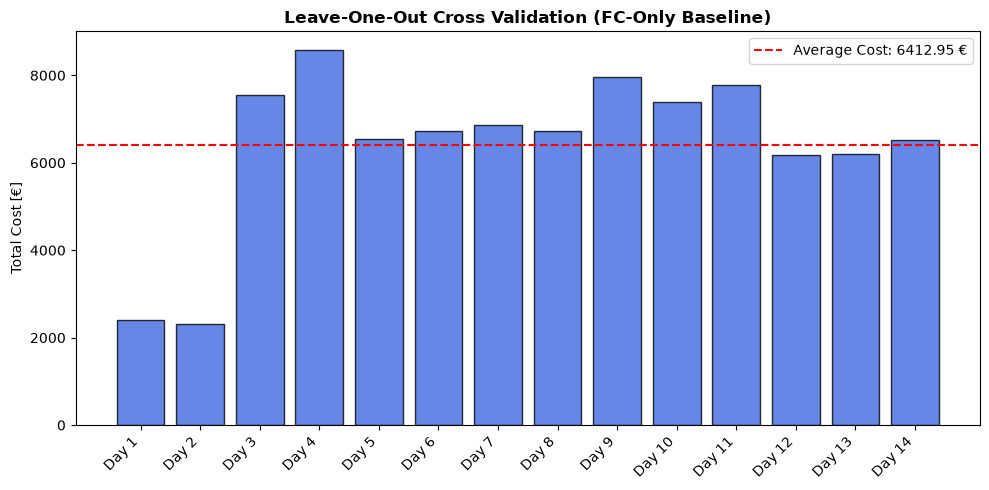

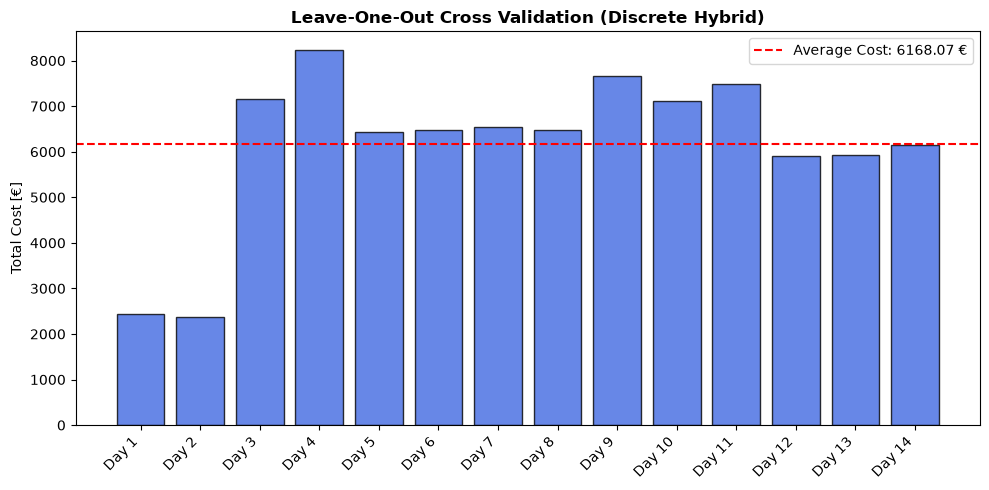

In [6]:
print("\n--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---")

# Note: Running LOO on all 5 approaches might take a couple of minutes due to 4D solves.
# Let's compare the main engineering deployable hybrid against the legacy baseline.

df_loo_legacy = benchmarker.run_leave_one_out(approaches["1. FC-Only Baseline"])
display(df_loo_legacy)

df_loo_hybrid = benchmarker.run_leave_one_out(approaches["3. Hybrid (Discrete Tracking)"])
display(df_loo_hybrid)

# Visualize the day-to-day volatility
plot_benchmarker_results(df_loo_legacy, title="Leave-One-Out Cross Validation (FC-Only Baseline)", plot_type='bar')
plot_benchmarker_results(df_loo_hybrid, title="Leave-One-Out Cross Validation (Discrete Hybrid)", plot_type='bar')

In [7]:
print("\n--- APPROACH C: FORWARD CHAINING (Learning Curve) ---")
# Evaluate how the policy improves as the agent gathers chronological data
# Using the Lookahead Optimum to see the absolute theoretical ceiling of the ship's capabilities

df_for_opt = benchmarker.run_forward_chaining(approaches["5. Hybrid (Lookahead Optimum)"])
display(df_for_opt)

plot_benchmarker_results(df_for_opt, title="Forward Chaining Learning Curve (Theoretical Optimum)", plot_type='line')


--- APPROACH C: FORWARD CHAINING (Learning Curve) ---


KeyboardInterrupt: 